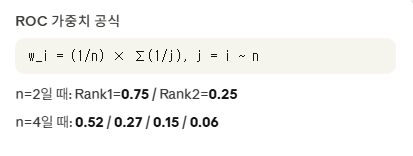

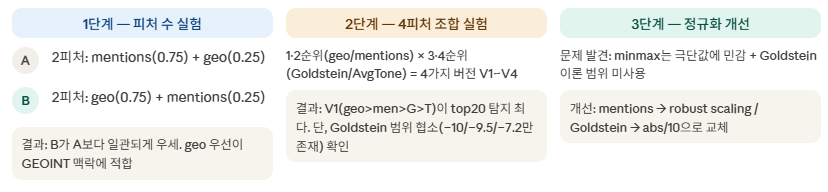

In [7]:
import pandas as pd
import numpy as np
import yaml
import os
from geopy.distance import geodesic
from shapely.geometry import Point, LineString
import geopy.distance

df = pd.read_csv(r"C:\Users\angel\DS8_SIA\DS8_SIA_Project\project\01_data\processed\events_filtered.csv")
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'])

In [12]:
config_path = os.path.join("C:/Users/angel/DS8_SIA/DS8_SIA_Project/project/config.yaml")
with open(config_path, encoding="utf-8") as f:
    config = yaml.safe_load(f)

In [13]:
config

{'spike_detection': {'mention_percentile': 95, 'ma_windows': [7, 14, 30]},
 'priority_score': {'weights': {'num_mentions': 0.5,
   'goldstein': 0.1,
   'avg_tone': 0.2,
   'geo_distance': 0.2},
  'avg_tone_threshold': -3,
  'taiwan_strait': {'line_start': [27.0, 122.0], 'line_end': [23.0, 118.0]},
  'geo_distance_bins': [{'max_km': 22.2, 'score': 1.0},
   {'max_km': 88.9, 'score': 0.75},
   {'max_km': 177.8, 'score': 0.5},
   {'max_km': 355.6, 'score': 0.25},
   {'max_km': 99999, 'score': 0.1}]}}

In [9]:
# ── 정규화 (0~1) ─────────────────────────────────────────
def minmax(series):
    return (series - series.min()) / (series.max() - series.min() + 1e-9)

df['score_mentions'] = minmax(df['NumMentions'])

In [14]:
# ── 위치 점수 ─────────────────────────────────────────────
MEDIAN_LINE = LineString([(122.0, 27.0), (118.0, 23.0)])
geo_bins = config['priority_score']['geo_distance_bins']

def calc_geo_score(lat, lon):
    try:
        point = Point(lon, lat)
        nearest = MEDIAN_LINE.interpolate(MEDIAN_LINE.project(point))
        dist_km = geopy.distance.geodesic(
            (lat, lon), (nearest.y, nearest.x)
        ).km
        for bin_ in geo_bins:
            if dist_km <= bin_['max_km']:
                return bin_['score']
    except:
        return 0.0

df['score_geo'] = df.apply(
    lambda row: calc_geo_score(row['ActionGeo_Lat'], row['ActionGeo_Long']),
    axis=1
)

In [16]:
# ── ROC 가중치 적용 (Rank-Order Centroid, n=2) ────────────
# Rank 1 → 0.75 / Rank 2 → 0.25
df['score_roc_A'] = df['score_mentions'] * 0.75 + df['score_geo'] * 0.25  # 기사량 우선
df['score_roc_B'] = df['score_mentions'] * 0.25 + df['score_geo'] * 0.75  # 위치중요도 우선

In [20]:
# ── 저장 ─────────────────────────────────────────────────
df_out = df.sort_values('score_roc_B', ascending=False)  # 기본 출력은 B 기준
df_out.to_csv("roc_weight.csv", index=False)

In [ ]:
print(f"Priority Score 산출 완료: {len(df_out)}행")
print(f"\n[Version A - 기사량 우선 상위 5]")
print(df_out.nlargest(5, 'score_roc_A')[['SQLDATE','NumMentions','score_mentions','score_geo','score_roc_A']].to_string(index=False))
print(f"\n[Version B - 위치중요도 우선 상위 5]")
print(df_out.nlargest(5, 'score_roc_B')[['SQLDATE','NumMentions','score_mentions','score_geo','score_roc_B']].to_string(index=False))

Priority Score 산출 완료: 503행

[Version A - 기사량 우선 상위 5]
   SQLDATE  NumMentions  score_mentions  score_geo  score_roc_A
2021-01-19         1406        0.956522        1.0     0.967391
2020-12-31         1190        0.805049        1.0     0.853787
2016-05-20         1468        1.000000        0.1     0.775000
2022-07-30         1465        0.997896        0.1     0.773422
2022-08-07         1420        0.966339        0.1     0.749755

[Version B - 위치중요도 우선 상위 5]
   SQLDATE  NumMentions  score_mentions  score_geo  score_roc_B
2021-01-19         1406        0.956522        1.0     0.989130
2020-12-31         1190        0.805049        1.0     0.951262
2022-08-04          536        0.346424        1.0     0.836606
2024-12-11          374        0.232819        1.0     0.808205
2021-09-23          360        0.223001        1.0     0.805750


In [22]:
print(f"\n[Version A - 기사량 우선 상위 20]")
print(df_out.nlargest(20, 'score_roc_A')[['SQLDATE','NumMentions','score_mentions','score_geo','score_roc_A']].to_string(index=False))
print(f"\n[Version B - 위치중요도 우선 상위 20]")
print(df_out.nlargest(20, 'score_roc_B')[['SQLDATE','NumMentions','score_mentions','score_geo','score_roc_B']].to_string(index=False))


[Version A - 기사량 우선 상위 20]
   SQLDATE  NumMentions  score_mentions  score_geo  score_roc_A
2021-01-19         1406        0.956522       1.00     0.967391
2020-12-31         1190        0.805049       1.00     0.853787
2016-05-20         1468        1.000000       0.10     0.775000
2022-07-30         1465        0.997896       0.10     0.773422
2022-08-07         1420        0.966339       0.10     0.749755
2015-11-07         1052        0.708275       0.10     0.556206
2025-02-27         1026        0.690042       0.10     0.542532
2022-08-04          536        0.346424       1.00     0.509818
2016-08-01          932        0.624123       0.10     0.493093
2016-08-01          932        0.624123       0.10     0.493093
2025-02-27          609        0.397616       0.75     0.485712
2021-07-08          870        0.580645       0.10     0.460484
2021-10-03          840        0.559607       0.10     0.444705
2024-12-11          374        0.232819       1.00     0.424614
2021-09-23  

### goldstein, avgTone 피쳐 추가 실험

In [23]:
from fractions import Fraction

# ── ROC 가중치 계산 (Rank-Order Centroid, n=4) ───────────
# 공식: w_i = (1/n) * Σ(1/j),  j = i ~ n
# 결과: [0.5208, 0.2708, 0.1458, 0.0625]
def calc_roc_weights(n: int) -> list[float]:
    return [
        float(Fraction(1, n) * sum(Fraction(1, j) for j in range(i, n + 1)))
        for i in range(1, n + 1)
    ]
 
W = calc_roc_weights(4)
 
print("=" * 52)
print("ROC 가중치 (n=4)")
print("=" * 52)
for i, w in enumerate(W):
    bar = "█" * int(w * 40)
    print(f"  Rank {i+1}: {w:.4f}  {bar}")
print(f"  합계  : {sum(W):.4f}\n")

ROC 가중치 (n=4)
  Rank 1: 0.5208  ████████████████████
  Rank 2: 0.2708  ██████████
  Rank 3: 0.1458  █████
  Rank 4: 0.0625  ██
  합계  : 1.0000



In [24]:
# ── 4가지 버전 정의 ──────────────────────────────────────
# 1·2순위 고정 조합 (geo/mentions) × 3·4순위 조합 (goldstein/avgtone)
VERSIONS = {
    "V1": ("geo", "mentions", "goldstein", "avgtone"),  # geo 우선, G>T
    "V2": ("geo", "mentions", "avgtone",   "goldstein"),# geo 우선, T>G
    "V3": ("mentions", "geo", "goldstein", "avgtone"),  # mentions 우선, G>T
    "V4": ("mentions", "geo", "avgtone",   "goldstein"),# mentions 우선, T>G
}
 
print("4가지 실험 버전")
print("-" * 52)
for name, order in VERSIONS.items():
    detail = " > ".join(f"{f}({W[i]:.4f})" for i, f in enumerate(order))
    print(f"  {name}: {detail}")
print()

4가지 실험 버전
----------------------------------------------------
  V1: geo(0.5208) > mentions(0.2708) > goldstein(0.1458) > avgtone(0.0625)
  V2: geo(0.5208) > mentions(0.2708) > avgtone(0.1458) > goldstein(0.0625)
  V3: mentions(0.5208) > geo(0.2708) > goldstein(0.1458) > avgtone(0.0625)
  V4: mentions(0.5208) > geo(0.2708) > avgtone(0.1458) > goldstein(0.0625)



In [25]:
df = pd.read_csv(r"C:\Users\angel\DS8_SIA\DS8_SIA_Project\project\01_data\processed\events_filtered.csv")
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'])

In [26]:
AVG_TONE_THRESHOLD = -3.0

# ── 피처 정규화 ──────────────────────────────────────────
def minmax(series: pd.Series) -> pd.Series:
    mn, mx = series.min(), series.max()
    return (series - mn) / (mx - mn + 1e-9)
 
df["score_mentions"]  = minmax(df["NumMentions"])
df["score_goldstein"] = minmax(df["GoldsteinScale"].abs())
 
# AvgTone: 전체 기준 minmax 후 threshold 이하만 반영
#   → threshold 이상은 0으로 처리 (중립/긍정 톤은 점수 기여 없음)
tone_norm = minmax(df["AvgTone"].abs())
df["score_avgtone"] = np.where(df["AvgTone"] < AVG_TONE_THRESHOLD, tone_norm, 0.0)

In [27]:
# ── 위치 점수 (대만해협 중간선 기준 거리) ────────────────
MEDIAN_LINE = LineString([(122.0, 27.0), (118.0, 23.0)])
 
GEO_BINS = [
    {"max_km":  50,  "score": 1.00},   # 중간선 인접 (~제주~푸젠 사이 핵심구역)
    {"max_km": 150,  "score": 0.75},   # 근접 전략 지역
    {"max_km": 300,  "score": 0.50},   # 대만해협 영향권
    {"max_km": 500,  "score": 0.25},   # 주변 해역
    {"max_km": 9999, "score": 0.10},   # 그 외
]
 
def calc_geo_score(lat: float, lon: float) -> float:
    try:
        point   = Point(lon, lat)
        nearest = MEDIAN_LINE.interpolate(MEDIAN_LINE.project(point))
        dist_km = geopy.distance.geodesic(
            (lat, lon), (nearest.y, nearest.x)
        ).km
        for bin_ in GEO_BINS:
            if dist_km <= bin_["max_km"]:
                return bin_["score"]
        return 0.10  # fallthrough 방지
    except Exception:
        return 0.0
 
df["score_geo"] = df.apply(
    lambda r: calc_geo_score(r["ActionGeo_Lat"], r["ActionGeo_Long"]), axis=1
)

In [28]:
print("피처 정규화 완료")
for col in ["score_mentions", "score_goldstein", "score_avgtone", "score_geo"]:
    s = df[col]
    print(f"  {col:<20}: mean={s.mean():.3f}  min={s.min():.3f}  max={s.max():.3f}")
print(f"  score_avgtone=0 비율 : {(df['score_avgtone']==0).mean()*100:.1f}%")
print(f"  score_geo unique     : {sorted(df['score_geo'].unique())}\n")
 

피처 정규화 완료
  score_mentions      : mean=0.072  min=0.000  max=1.000
  score_goldstein     : mean=0.570  min=0.000  max=1.000
  score_avgtone       : mean=0.226  min=0.000  max=1.000
  score_geo           : mean=0.373  min=0.100  max=1.000
  score_avgtone=0 비율 : 56.9%
  score_geo unique     : [np.float64(0.1), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]



In [29]:
# ── 버전별 점수·순위 계산 ────────────────────────────────
FEAT_COL = {
    "geo":       "score_geo",
    "mentions":  "score_mentions",
    "goldstein": "score_goldstein",
    "avgtone":   "score_avgtone",
}
 
for vname, order in VERSIONS.items():
    df[f"score_{vname}"] = sum(
        df[FEAT_COL[feat]] * W[i] for i, feat in enumerate(order)
    )
    df[f"rank_{vname}"] = (
        df[f"score_{vname}"].rank(ascending=False, method="min").astype(int)
    )

In [30]:
# ── 버전간 점수 상관관계 ─────────────────────────────────
score_cols = [f"score_{v}" for v in VERSIONS]
print("버전간 점수 상관관계")
print(df[score_cols].corr().round(3).to_string())
print()

버전간 점수 상관관계
          score_V1  score_V2  score_V3  score_V4
score_V1     1.000     0.970     0.890     0.878
score_V2     0.970     1.000     0.818     0.890
score_V3     0.890     0.818     1.000     0.939
score_V4     0.878     0.890     0.939     1.000



In [31]:
KEY_EVENTS = [
    ("2024-05-23", "2024-05-24", "리젠-2024A 연합훈련"),
    ("2023-04-08", "2023-04-10", "연합이검 훈련"),
    ("2022-08-04", "2022-08-08", "펠로시 방문 봉쇄훈련"),
    ("2021-10-01", "2021-10-04", "국경절 역대 최대 무력시위"),
    ("2020-09-18", "2020-09-19", "미 차관 방문 / 중간선 침범"),
    ("2018-04-18", "2018-04-18", "대만해협 실사격 훈련"),
    ("2016-07-01", "2016-07-31", "남중국해 중재판결 긴장"),
    ("2015-07-01", "2015-07-31", "주리허 총통부 모형"),
]

In [32]:
# ── 주요 이벤트 순위 비교 ────────────────────────────────
print("=" * 80)
print(f"주요 이벤트 순위 비교  (전체 {len(df)}건 기준)")
print("=" * 80)
print(f"{'이벤트':<24} {'날짜':<12} {'men':>4} {'geo':>4} {'G':>4} {'T':>4}  "
      + "  ".join(f"{v:>6}" for v in VERSIONS))
print("-" * 80)
 
def rank_tag(r: int) -> str:
    if r <= 20: return f"{r:>4}★"
    if r <= 60: return f"{r:>4}△"
    return            f"{r:>5} "
 
total = len(df)
for start, end, label in KEY_EVENTS:
    s, e = pd.Timestamp(start), pd.Timestamp(end)
    sub  = df[(df["SQLDATE"] >= s) & (df["SQLDATE"] <= e)]
 
    if len(sub) == 0:
        print(f"{label:<24}  (데이터 없음)")
        continue
 
    best = sub.loc[sub["rank_V1"].idxmin()]
    ranks_str = "  ".join(rank_tag(int(best[f"rank_{v}"])) for v in VERSIONS)
 
    print(
        f"{label:<24} {str(best['SQLDATE'].date()):<12} "
        f"{int(best['NumMentions']):>4} {best['score_geo']:>4.2f} "
        f"{best['score_goldstein']:>4.2f} {best['score_avgtone']:>4.2f}  "
        f"{ranks_str}"
    )
 
print(f"\n★ = 상위 20위  △ = 21~60위")

주요 이벤트 순위 비교  (전체 503건 기준)
이벤트                      날짜            men  geo    G    T      V1      V2      V3      V4
--------------------------------------------------------------------------------
리젠-2024A 연합훈련            2024-05-23    100 0.75 0.00 0.56    136      90     179     104 
연합이검 훈련                  2023-04-10    310 1.00 1.00 0.00     5★     8★    12★    16★
펠로시 방문 봉쇄훈련              2022-08-04    536 1.00 1.00 0.58     2★     3★     4★     4★
국경절 역대 최대 무력시위           2021-10-02     57 0.75 1.00 0.57    43△    42△     62     57△
미 차관 방문 / 중간선 침범         2020-09-19    463 0.75 1.00 0.00    15★    48△    13★    17★
대만해협 실사격 훈련              2018-04-18    184 0.75 0.00 0.63    129      81     148      68 
남중국해 중재판결 긴장             2016-07-01    194 0.75 1.00 0.52    19★    29△    26△    27△
주리허 총통부 모형               2015-07-20    172 0.75 1.00 0.00     69      96     55△     99 

★ = 상위 20위  △ = 21~60위


In [33]:
OUTPUT_PATH = "roc_weight_experiment.csv"

# ── 결과 저장 ────────────────────────────────────────────
feat_cols = ["score_mentions", "score_geo", "score_goldstein", "score_avgtone"]
out_cols  = (
    ["SQLDATE", "NumMentions", "GoldsteinScale", "AvgTone",
     "ActionGeo_Lat", "ActionGeo_Long"]
    + feat_cols
    + [f"score_{v}" for v in VERSIONS]
    + [f"rank_{v}"  for v in VERSIONS]
)
 
df[out_cols].sort_values("rank_V1").to_csv(OUTPUT_PATH, index=False)
print(f"\n결과 저장 → {OUTPUT_PATH}")


결과 저장 → roc_weight_experiment.csv


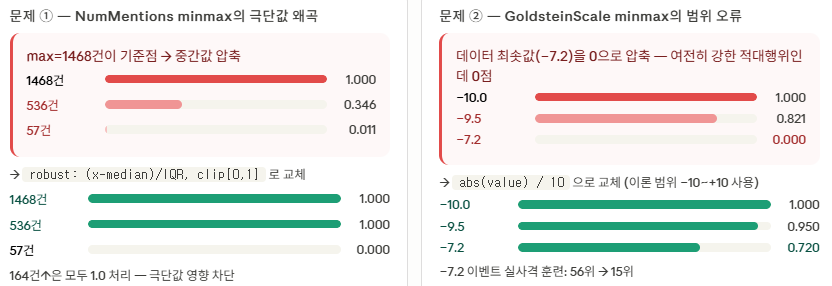

### 정규화 다르게, 실험

In [ ]:
"""
정규화 방법 비교 실험 (기존 vs 수정)
 
비교 버전 6개
  기존 A   : 2피처 · mentions_minmax(0.75) + geo(0.25)
  기존 B   : 2피처 · geo(0.75) + mentions_minmax(0.25)
  기존 V1  : 4피처 · geo(0.52) > mentions_minmax(0.27) > G_minmax(0.15) > tone(0.06)
  수정 A   : 2피처 · mentions_robust(0.75) + geo(0.25)
  수정 B   : 2피처 · geo(0.75) + mentions_robust(0.25)          ★ 권장
  수정 V1  : 4피처 · geo(0.52) > mentions_robust(0.27) > G_abs10(0.15) > tone(0.06)
 
정규화 변경 내용
  NumMentions  : minmax → robust (중앙값/IQR 기준, clip 0~1)
  GoldsteinScale: minmax_data → abs/10 (이론 범위 −10~+10 사용)
"""

'\n정규화 방법 비교 실험 (기존 vs 수정)\n \n비교 버전 6개\n  기존 A   : 2피처 · mentions_minmax(0.75) + geo(0.25)\n  기존 B   : 2피처 · geo(0.75) + mentions_minmax(0.25)\n  기존 V1  : 4피처 · geo(0.52) > mentions_minmax(0.27) > G_minmax(0.15) > tone(0.06)\n  수정 A   : 2피처 · mentions_robust(0.75) + geo(0.25)\n  수정 B   : 2피처 · geo(0.75) + mentions_robust(0.25)          ★ 권장\n  수정 V1  : 4피처 · geo(0.52) > mentions_robust(0.27) > G_abs10(0.15) > tone(0.06)\n \n정규화 변경 내용\n  NumMentions  : minmax → robust (중앙값/IQR 기준, clip 0~1)\n  GoldsteinScale: minmax_data → abs/10 (이론 범위 −10~+10 사용)\n'

In [35]:
df = pd.read_csv(r"C:\Users\angel\DS8_SIA\DS8_SIA_Project\project\01_data\processed\events_filtered.csv")
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'])

In [36]:
OUTPUT_PATH = "roc_normalization_experiment.csv"

In [37]:
AVG_TONE_THRESHOLD = -3.0
 
GEO_BINS = [
    {"max_km":  22.2,  "score": 1.00},
    {"max_km": 88.9,  "score": 0.75},
    {"max_km": 177.8,  "score": 0.50},
    {"max_km": 355.6,  "score": 0.25},
    {"max_km": 99999, "score": 0.10},
]
 
KEY_EVENTS = [
    ("2024-05-23", "2024-05-24", "리젠-2024A 연합훈련"),
    ("2023-04-08", "2023-04-10", "연합이검 훈련"),
    ("2022-08-04", "2022-08-08", "펠로시 방문 봉쇄훈련"),
    ("2021-10-01", "2021-10-04", "국경절 역대 최대 무력시위"),
    ("2020-09-18", "2020-09-19", "미 차관 방문 / 중간선 침범"),
    ("2018-04-18", "2018-04-18", "대만해협 실사격 훈련"),
    ("2016-07-01", "2016-07-31", "남중국해 중재판결 긴장"),
    ("2015-07-01", "2015-07-31", "주리허 총통부 모형"),
]

In [38]:
# ── ROC 가중치 (n=4) ──────────────────────────────────────
# Rank1=0.5208 / Rank2=0.2708 / Rank3=0.1458 / Rank4=0.0625
def calc_roc_weights(n):
    return [float(Fraction(1,n) * sum(Fraction(1,j) for j in range(i, n+1)))
            for i in range(1, n+1)]
 
W = calc_roc_weights(4)

In [39]:
# ── geo 점수 계산 ─────────────────────────────────────────
MEDIAN_LINE = LineString([(122.0, 27.0), (118.0, 23.0)])
 
def calc_geo_score(lat, lon):
    try:
        point   = Point(lon, lat)
        nearest = MEDIAN_LINE.interpolate(MEDIAN_LINE.project(point))
        dist_km = geopy.distance.geodesic(
            (lat, lon), (nearest.y, nearest.x)
        ).km
        for bin_ in GEO_BINS:
            if dist_km <= bin_["max_km"]:
                return bin_["score"]
        return 0.10
    except Exception:
        return 0.0
 
df["score_geo"] = df.apply(
    lambda r: calc_geo_score(r["ActionGeo_Lat"], r["ActionGeo_Long"]), axis=1
)

In [40]:
# ════════════════════════════════════════════════════════
# 정규화 함수 정의
# ════════════════════════════════════════════════════════
def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)
 
def robust_clip(s):
    """
    Robust scaling: (x - median) / IQR, clip [0, 1]
    - 중앙값 이하 → 0  (하위 50% 이벤트는 기여 없음)
    - 상위 25%(IQR 1배 초과) → 1  (고트래픽 이벤트는 동등 취급)
    - 극단값 영향 차단
    """
    med = s.median()
    iqr = s.quantile(0.75) - s.quantile(0.25)
    return np.clip((s - med) / (iqr + 1e-9), 0, 1)
 
# ── 피처별 정규화 적용 ────────────────────────────────────
# NumMentions
men_minmax = minmax(df["NumMentions"])
men_robust = robust_clip(df["NumMentions"])
 
# GoldsteinScale
gol_minmax = minmax(df["GoldsteinScale"].abs())   # 기존: 데이터 범위 기준
gol_abs10  = df["GoldsteinScale"].abs() / 10.0    # 수정: 이론 범위(−10~+10)
 
# AvgTone: 공통 사용 (두 방식 모두 동일)
tone_norm  = minmax(df["AvgTone"].abs())
score_tone = pd.Series(
    np.where(df["AvgTone"] < AVG_TONE_THRESHOLD, tone_norm, 0.0),
    index=df.index
)
 
geo = df["score_geo"]

In [41]:
# ════════════════════════════════════════════════════════
# 6개 버전 점수 계산
# ════════════════════════════════════════════════════════
VERSIONS = {
    "기존_A":  geo * 0.25  + men_minmax * 0.75,
    "기존_B":  geo * 0.75  + men_minmax * 0.25,
    "기존_V1": geo * W[0]  + men_minmax * W[1] + gol_minmax * W[2] + score_tone * W[3],
    "수정_A":  geo * 0.25  + men_robust * 0.75,
    "수정_B":  geo * 0.75  + men_robust * 0.25,
    "수정_V1": geo * W[0]  + men_robust * W[1] + gol_abs10  * W[2] + score_tone * W[3],
}

In [42]:
for vname, score in VERSIONS.items():
    df[f"score_{vname}"] = score
    df[f"rank_{vname}"]  = score.rank(ascending=False, method="min").astype(int)

In [43]:
# ════════════════════════════════════════════════════════
# 정규화 값 비교 출력
# ════════════════════════════════════════════════════════
print("=" * 60)
print("정규화 변경 효과 확인")
print("=" * 60)
 
print("\n[NumMentions] 주요 구간별 비교")
print(f"  중앙값={df['NumMentions'].median():.0f}  "
      f"IQR={df['NumMentions'].quantile(0.75)-df['NumMentions'].quantile(0.25):.0f}  "
      f"max={df['NumMentions'].max():.0f}")
print(f"  {'원본':>6}  {'minmax':>8}  {'robust':>8}  의미")
for v in [42, 57, 100, 164, 184, 310, 536, 1420]:
    idx = df[df["NumMentions"] == v].index
    if not len(idx):
        continue
    mm = float(men_minmax.iloc[idx[0]])
    rb = float(men_robust.iloc[idx[0]])
    note = ""
    if rb == 0.0:  note = "← 하위 50% (0 처리)"
    elif rb == 1.0: note = "← 상위 25% 이상 (1 처리)"
    print(f"  {v:>6}건  {mm:>8.3f}  {rb:>8.3f}  {note}")
 
print("\n[GoldsteinScale] 정규화 비교")
print(f"  {'원본':>6}  {'minmax_data':>12}  {'abs/10':>8}  변화")
for gval in [-10.0, -9.5, -7.2]:
    mm = float(minmax(df["GoldsteinScale"].abs())[df["GoldsteinScale"] == gval].iloc[0])
    a10 = abs(gval) / 10.0
    diff = a10 - mm
    note = f"{'↑ +' if diff > 0 else '→ '}{abs(diff):.3f}" if diff != 0 else "동일"
    print(f"  {gval:>6.1f}  {mm:>12.3f}  {a10:>8.3f}  {note}")

정규화 변경 효과 확인

[NumMentions] 주요 구간별 비교
  중앙값=84  IQR=80  max=1468
      원본    minmax    robust  의미
      42건     0.000     0.000  ← 하위 50% (0 처리)
      57건     0.011     0.000  ← 하위 50% (0 처리)
     100건     0.041     0.201  
     184건     0.100     1.000  ← 상위 25% 이상 (1 처리)
     310건     0.188     1.000  ← 상위 25% 이상 (1 처리)
     536건     0.346     1.000  ← 상위 25% 이상 (1 처리)
    1420건     0.966     1.000  ← 상위 25% 이상 (1 처리)

[GoldsteinScale] 정규화 비교
      원본   minmax_data    abs/10  변화
   -10.0         1.000     1.000  ↑ +0.000
    -9.5         0.821     0.950  ↑ +0.129
    -7.2         0.000     0.720  ↑ +0.720


In [44]:
# ════════════════════════════════════════════════════════
# 버전별 성능 요약
# ════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("버전별 성능 요약")
print("=" * 60)
 
total = len(df)
feat_n = {"기존_A":"2피처", "기존_B":"2피처", "기존_V1":"4피처",
          "수정_A":"2피처", "수정_B":"2피처", "수정_V1":"4피처"}
 
print(f"\n  {'버전':<10} {'피처':>5}  {'top20':>6}  {'top60':>6}  {'avg순위':>8}")
print(f"  {'-'*45}")
 
all_ranks = {}
for vname in VERSIONS:
    event_ranks = []
    for start, end, label in KEY_EVENTS:
        s, e = pd.Timestamp(start), pd.Timestamp(end)
        sub  = df[(df["SQLDATE"] >= s) & (df["SQLDATE"] <= e)]
        if not len(sub):
            continue
        r = int(df.loc[sub.index, f"rank_{vname}"].min())
        event_ranks.append(r)
    all_ranks[vname] = event_ranks
    top20 = sum(r <= 20  for r in event_ranks)
    top60 = sum(r <= 60  for r in event_ranks)
    avg   = np.mean(event_ranks)
    marker = " ★" if vname == "수정_B" else ""
    print(f"  {vname:<10} {feat_n[vname]:>5}  {top20:>4}건  {top60:>4}건  {avg:>7.1f}{marker}")
 


버전별 성능 요약

  버전            피처   top20   top60     avg순위
  ---------------------------------------------
  기존_A         2피처     3건     6건     45.9
  기존_B         2피처     3건     7건     35.0
  기존_V1        4피처     3건     6건     44.1
  수정_A         2피처     7건     8건     12.8
  수정_B         2피처     5건     7건     25.8 ★
  수정_V1        4피처     5건     7건     30.8


In [45]:
# ════════════════════════════════════════════════════════
# 이벤트별 순위 비교
# ════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print(f"이벤트별 순위 비교  (전체 {total}건 기준)")
print("=" * 60)
 
def rank_tag(r):
    if r <= 20:  return f"{r:3}★"
    if r <= 60:  return f"{r:3}△"
    return           f"{r:3} "
 
col_w = 8
header = (f"\n  {'이벤트':<26} {'G':>5} {'men':>5} "
          f"| {'기존A':>{col_w}} {'기존B':>{col_w}} {'기존V1':>{col_w}} "
          f"| {'수정A':>{col_w}} {'수정B':>{col_w}} {'수정V1':>{col_w}}")
print(header)
print(f"  {'-'*85}")
 
for start, end, label in KEY_EVENTS:
    s, e = pd.Timestamp(start), pd.Timestamp(end)
    sub  = df[(df["SQLDATE"] >= s) & (df["SQLDATE"] <= e)]
    if not len(sub):
        print(f"  {label:<26}  (데이터 없음)")
        continue
    best = sub.loc[df.loc[sub.index, "rank_기존_V1"].idxmin()]
    ranks = {v: int(best[f"rank_{v}"]) for v in VERSIONS}
 
    print(
        f"  {label:<26} {best['GoldsteinScale']:>5.1f} {int(best['NumMentions']):>5} "
        f"| {rank_tag(ranks['기존_A']):>{col_w}} {rank_tag(ranks['기존_B']):>{col_w}} {rank_tag(ranks['기존_V1']):>{col_w}} "
        f"| {rank_tag(ranks['수정_A']):>{col_w}} {rank_tag(ranks['수정_B']):>{col_w}} {rank_tag(ranks['수정_V1']):>{col_w}}"
    )
 
print(f"\n  ★ = 상위 20위  △ = 21~60위")


이벤트별 순위 비교  (전체 503건 기준)

  이벤트                            G   men |      기존A      기존B     기존V1 |      수정A      수정B     수정V1
  -------------------------------------------------------------------------------------
  리젠-2024A 연합훈련               -7.2   100 |     128       95      148  |     189       97      155 
  연합이검 훈련                    -10.0   310 |      20★       6★       5★ |       1★       1★       3★
  펠로시 방문 봉쇄훈련                -10.0   536 |       8★       3★       2★ |       1★       1★       1★
  국경절 역대 최대 무력시위             -10.0    57 |     189      145       67  |     249      106      165 
  미 차관 방문 / 중간선 침범            -7.2   176 |      31△      11★      32△ |       1★       1★       9★
  대만해협 실사격 훈련                 -7.2   184 |      57△      35△      56△ |      12★      15★      19★
  남중국해 중재판결 긴장               -10.0   135 |      67       37△      15★ |     119       37△      21△
  주리허 총통부 모형                 -10.0   172 |      60△      36△      28△ |      12★      15★    

In [46]:
# ════════════════════════════════════════════════════════
# 수정 전후 변화량
# ════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("수정 전후 순위 변화  (+= 개선, -= 악화)")
print("=" * 60)
print(f"\n  {'이벤트':<26}  {'A 변화':>8}  {'B 변화':>8}  {'V1 변화':>9}")
print(f"  {'-'*60}")
 
for start, end, label in KEY_EVENTS:
    s, e = pd.Timestamp(start), pd.Timestamp(end)
    sub  = df[(df["SQLDATE"] >= s) & (df["SQLDATE"] <= e)]
    if not len(sub):
        continue
    best = sub.loc[df.loc[sub.index, "rank_기존_V1"].idxmin()]
    da = int(best["rank_기존_A"])  - int(best["rank_수정_A"])
    db = int(best["rank_기존_B"])  - int(best["rank_수정_B"])
    dv = int(best["rank_기존_V1"]) - int(best["rank_수정_V1"])
 
    def fmt_delta(d):
        if d > 0:  return f"+{d:4}↑"
        if d < 0:  return f"{d:4}↓"
        return f"  ±0 "
 
    print(f"  {label:<26}  {fmt_delta(da):>8}  {fmt_delta(db):>8}  {fmt_delta(dv):>9}")


수정 전후 순위 변화  (+= 개선, -= 악화)

  이벤트                             A 변화      B 변화      V1 변화
  ------------------------------------------------------------
  리젠-2024A 연합훈련                   -61↓       -2↓        -7↓
  연합이검 훈련                       +  19↑    +   5↑     +   2↑
  펠로시 방문 봉쇄훈련                   +   7↑    +   2↑     +   1↑
  국경절 역대 최대 무력시위                  -60↓    +  39↑       -98↓
  미 차관 방문 / 중간선 침범              +  30↑    +  10↑     +  23↑
  대만해협 실사격 훈련                   +  45↑    +  20↑     +  37↑
  남중국해 중재판결 긴장                    -52↓       ±0         -6↓
  주리허 총통부 모형                    +  48↑    +  21↑     +  12↑


In [47]:
# ════════════════════════════════════════════════════════
# 결과 저장
# ════════════════════════════════════════════════════════
score_cols = [f"score_{v}" for v in VERSIONS]
rank_cols  = [f"rank_{v}"  for v in VERSIONS]
out_cols   = (
    ["SQLDATE", "NumMentions", "GoldsteinScale", "AvgTone",
     "ActionGeo_Lat", "ActionGeo_Long", "score_geo"]
    + score_cols + rank_cols
)
 
df[out_cols].sort_values("rank_수정_B").to_csv(OUTPUT_PATH, index=False)
print(f"\n\n결과 저장 → {OUTPUT_PATH}")



결과 저장 → roc_normalization_experiment.csv


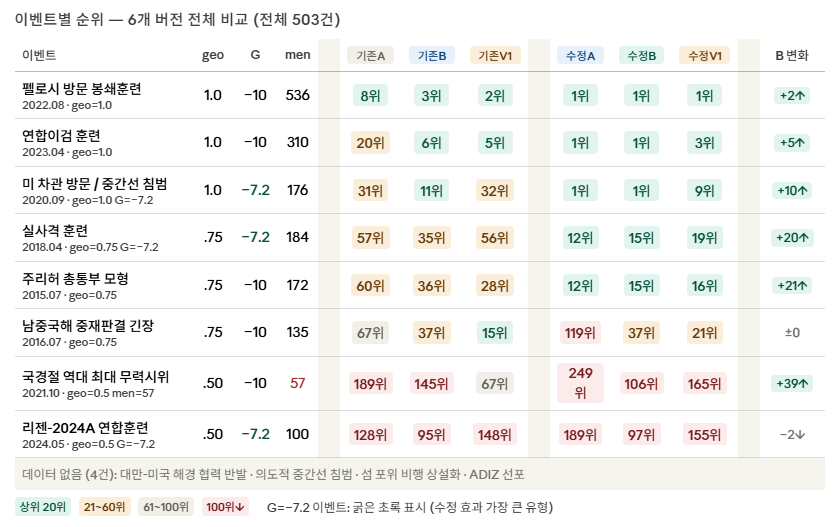

In [49]:
data = pd.read_csv("roc_normalization_experiment.csv")

In [50]:
data.head(3)

,SQLDATE,NumMentions,GoldsteinScale,AvgTone,ActionGeo_Lat,ActionGeo_Long,score_geo,score_기존_A,score_기존_B,score_기존_V1,score_수정_A,score_수정_B,score_수정_V1,rank_기존_A,rank_기존_B,rank_기존_V1,rank_수정_A,rank_수정_B,rank_수정_V1
0,2021-09-23,360,-7.2,-1.996044,24.0,119.0,1.0,0.417251,0.805750,0.581230,1.0,1.0,0.896667,15,5,19,1,1,9
1,2023-04-05,194,-10.0,-1.231359,24.0,119.0,1.0,0.329944,0.776648,0.695535,1.0,1.0,0.937500,27,9,7,1,1,3
2,2021-01-19,1406,-10.0,-1.271789,24.0,119.0,1.0,0.967391,0.989130,0.925725,1.0,1.0,0.937500,1,1,1,1,1,3


In [54]:
data['score_수정_B'].describe()

count    503.000000
mean       0.297320
std        0.223703
min        0.075000
25%        0.075000
50%        0.325000
75%        0.375000
max        1.000000
Name: score_수정_B, dtype: float64

<Axes: >

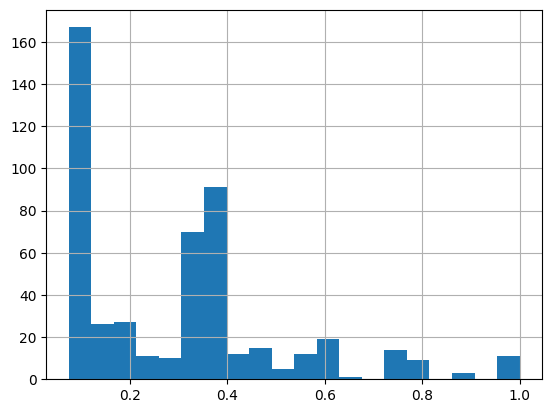

In [57]:
import seaborn as sns

data['score_수정_B'].hist(bins=20)


In [58]:
W

[0.5208333333333334, 0.2708333333333333, 0.14583333333333334, 0.0625]